# CardioIA — Fase 2, Ir Além 2: diagnóstico visual de ECG com rede neural MLP

Objetivo: classificar **imagens de batimentos cardíacos** como **normal** ou
**anormal** com uma rede neural do tipo **MLP (Perceptron Multicamadas)** em
Keras.

Roteiro:

1. Baixar o dataset recomendado (MIT-BIH, via Kaggle)
2. Transformar cada batimento em **imagem**
3. **Pré-processar** as imagens: tons de cinza, redimensionamento, normalização e achatamento
4. Montar um treino **balanceado** e manter o teste na **proporção real**
5. Criar e treinar a MLP
6. Avaliar acurácia, recall, precisão e matriz de confusão, comparando com um modelo que só responde "normal"
7. Discutir erros, limitações e vieses

> Projeto acadêmico. Nenhuma saída deste modelo substitui a leitura de um ECG por um profissional.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # esconde logs internos do TensorFlow

import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import kagglehub
import keras
import tensorflow as tf
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             classification_report, ConfusionMatrixDisplay)

SEED = 42  # mesma semente das outras partes do projeto
keras.utils.set_random_seed(SEED)           # Python, NumPy e TensorFlow
tf.config.experimental.enable_op_determinism()  # treino reprodutível
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

C:\Users\VictorRolim\source\repos\CardioIA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow 2.21.0 | Keras 3.15.1


## 1. O dataset

**ECG Heartbeat Categorization Dataset** (Kaggle, `shayanfazeli/heartbeat`),
o dataset recomendado no enunciado. Ele foi preparado por Kachuee, Fazeli e
Sarrafzadeh (2018) a partir do **MIT-BIH Arrhythmia Database** (PhysioNet):
48 gravações de ECG de 47 pacientes, feitas entre 1975 e 1979 no Beth Israel
Hospital, em Boston.

Cada linha do CSV é **um batimento**: 187 amostras do sinal elétrico (a 125 Hz,
normalizadas entre 0 e 1 e completadas com zeros no fim) e, na última coluna,
a classe, seguindo o padrão AAMI:

| Classe | Sigla | Significado |
|---|---|---|
| 0 | N | batimento **normal** |
| 1 | S | ectópico supraventricular (nasce acima dos ventrículos, nos átrios) |
| 2 | V | ectópico ventricular (nasce nos ventrículos) |
| 3 | F | fusão de batimento normal com ventricular |
| 4 | Q | não classificável / marcapasso |

Para a tarefa binária: **classe 0 = normal**, **classes 1 a 4 = anormal**.

O `kagglehub` baixa o dataset (~100 MB) na primeira execução e usa o cache
local nas seguintes. Os CSVs **não** ficam no repositório.

In [2]:
pasta = kagglehub.dataset_download("shayanfazeli/heartbeat")
treino = pd.read_csv(f"{pasta}/mitbih_train.csv", header=None).to_numpy(np.float32)
teste = pd.read_csv(f"{pasta}/mitbih_test.csv", header=None).to_numpy(np.float32)

sinais_treino, classe_treino = treino[:, :187], treino[:, 187].astype(int)
sinais_teste, classe_teste = teste[:, :187], teste[:, 187].astype(int)

NOMES_CLASSE = {0: "N (normal)", 1: "S (supraventricular)", 2: "V (ventricular)",
                3: "F (fusão)", 4: "Q (não classificável)"}
contagem = pd.DataFrame({
    "treino": np.bincount(classe_treino), "teste": np.bincount(classe_teste)},
    index=[NOMES_CLASSE[c] for c in range(5)])
contagem.loc["% normal"] = (contagem.iloc[0] / contagem.sum() * 100).round(1)
contagem

,treino,teste
N (normal),72471.0,18118.0
S (supraventricular),2223.0,556.0
V (ventricular),5788.0,1448.0
F (fusão),641.0,162.0
Q (não classificável),6431.0,1608.0
% normal,82.8,82.8


**O dataset é muito desbalanceado:** cerca de 83% dos batimentos são
normais. Isso reflete a realidade, já que a maioria dos batimentos de qualquer
pessoa é normal, mas cria uma armadilha. Um "modelo" que responde **sempre
"normal"**, sem aprender nada, já acerta ~83%, e mesmo assim deixa passar
**100% das anomalias**. Voltaremos a esse ponto na avaliação.

## 2. De sinal para imagem

O dataset recomendado traz **sinais numéricos**, não imagens. Como a proposta
é diagnóstico **visual**, convertemos cada batimento na imagem do seu traçado,
como ele apareceria num monitor ou no papel: linha escura sobre fundo claro,
**128×128 pixels, colorida (RGB)**.

O desenho é feito coluna a coluna. Em cada coluna de pixels, pintamos do ponto
mais baixo ao mais alto que o sinal atinge ali. Assim as subidas e descidas
bruscas do complexo QRS (o "pico" do batimento) ficam contínuas, sem falhas.

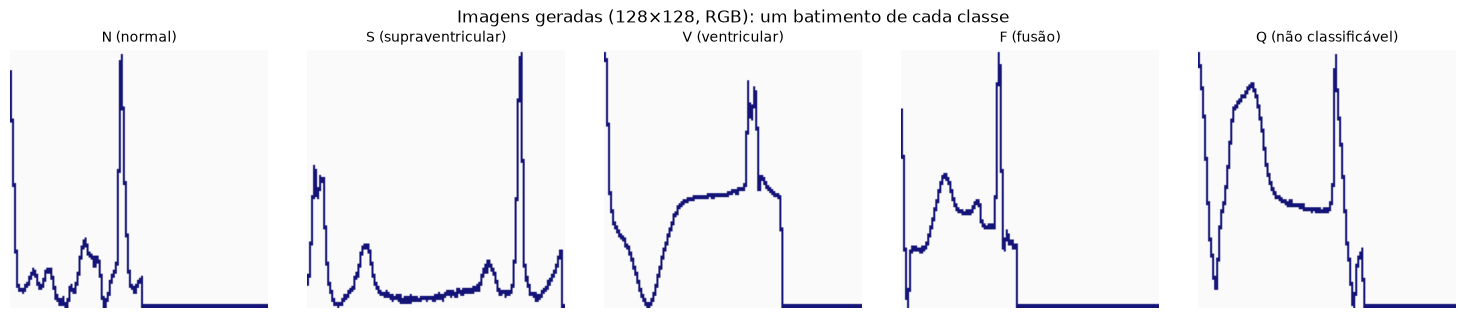

In [3]:
LADO_BRUTO = 128          # tamanho da imagem gerada
COR_TRACO = (20, 20, 120)  # azul-escuro, como tinta de ECG
COR_FUNDO = 250            # quase branco
N_PONTOS = 1000            # o sinal é reamostrado para o traçado ficar suave


def renderizar(sinais: np.ndarray) -> np.ndarray:
    """Converte um lote de sinais (B, 187) em imagens RGB (B, 128, 128, 3)."""
    lote = len(sinais)
    x_denso = np.linspace(0, 186, N_PONTOS)
    y_denso = np.stack([np.interp(x_denso, np.arange(187), s) for s in sinais])

    # Posição em pixels. O eixo y da imagem cresce para baixo, por isso o "1 -".
    px = np.round(x_denso / 186 * (LADO_BRUTO - 1)).astype(int)
    py = np.clip(np.round((1 - y_denso) * (LADO_BRUTO - 3)) + 1, 0, LADO_BRUTO - 1).astype(int)

    # Cada par de pontos vizinhos forma um segmento. Em cada coluna, pintamos
    # do menor ao maior y dos segmentos que passam por ela.
    baixo = np.minimum(py[:, :-1], py[:, 1:])
    alto = np.maximum(py[:, :-1], py[:, 1:])
    inicios = np.flatnonzero(np.r_[True, np.diff(px[:-1]) > 0])
    col_min = np.minimum.reduceat(baixo, inicios, axis=1)
    col_max = np.maximum.reduceat(alto, inicios, axis=1) + 1  # +1: traço com 2 px
    colunas = px[:-1][inicios]

    linhas = np.arange(LADO_BRUTO)[None, :, None]
    traco = (linhas >= col_min[:, None, :]) & (linhas <= col_max[:, None, :])

    imagens = np.full((lote, LADO_BRUTO, LADO_BRUTO, 3), COR_FUNDO, np.uint8)
    mascara = np.zeros((lote, LADO_BRUTO, LADO_BRUTO), bool)
    mascara[:, :, colunas] = traco
    imagens[mascara] = COR_TRACO
    return imagens


fig, eixos = plt.subplots(1, 5, figsize=(15, 3.2))
for c, eixo in enumerate(eixos):
    i = np.flatnonzero(classe_treino == c)[3]
    eixo.imshow(renderizar(sinais_treino[i:i + 1])[0])
    eixo.set_title(NOMES_CLASSE[c], fontsize=10)
    eixo.axis("off")
fig.suptitle("Imagens geradas (128×128, RGB): um batimento de cada classe")
plt.tight_layout()
plt.show()

## 3. Pré-processamento das imagens

Uma MLP recebe um **vetor de números**, não uma imagem. O pré-processamento
transforma cada imagem RGB 128×128 nesse vetor, em quatro passos:

| Passo | De → para | Por quê |
|---|---|---|
| **1. Tons de cinza** | 3 canais (RGB) → 1 canal | A cor não carrega informação diagnóstica. O que importa é a forma do traçado. Divide a entrada por 3. |
| **2. Redimensionar** | 128×128 → **32×32** | Uma MLP liga cada pixel a cada neurônio: com 128×128 seriam 16.384 entradas e mais de 4 milhões de pesos só na primeira camada. A seção 7 compara 32×32 com 64×64. |
| **3. Inverter e normalizar** | 0–255 → 0–1 | Redes neurais treinam melhor com entradas pequenas. Invertemos para o **fundo** valer 0 e o **traçado** ficar perto de 1 (≈0,88, porque o azul-escuro não é preto puro): o sinal fica onde há informação. |
| **4. Achatar** | 32×32 → vetor de 1.024 | Formato de entrada da camada densa. |

O redimensionamento usa interpolação bilinear, que suaviza o traço em vez de
apagá-lo (veja a linha de baixo da figura).

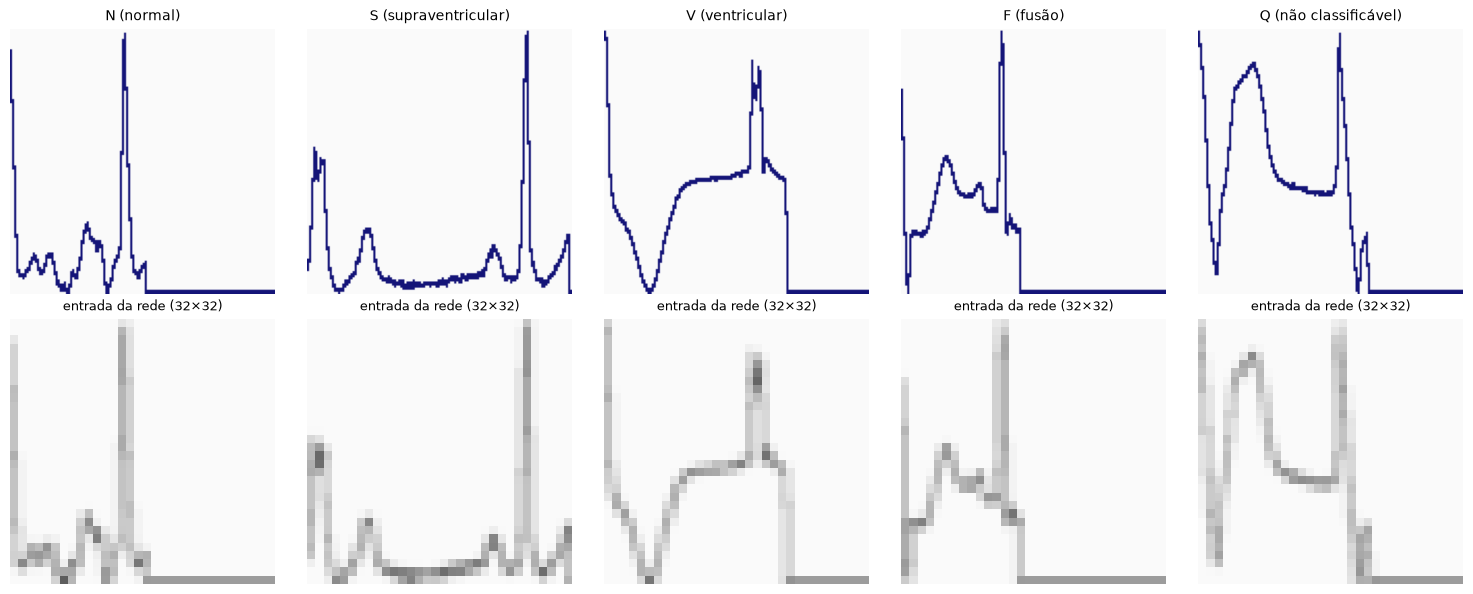

exemplos salvos em ['classe0_N_bruta.png', 'classe0_N_preprocessada.png', 'classe1_S_bruta.png', 'classe1_S_preprocessada.png', 'classe2_V_bruta.png', 'classe2_V_preprocessada.png', 'classe3_F_bruta.png', 'classe3_F_preprocessada.png', 'classe4_Q_bruta.png', 'classe4_Q_preprocessada.png']


In [4]:
LADO = 32  # resolução de entrada da rede


def preprocessar(imagens: np.ndarray, lado: int = LADO) -> np.ndarray:
    """(B, 128, 128, 3) uint8 → (B, lado*lado) float32 em [0, 1]."""
    saida = np.empty((len(imagens), lado * lado), np.float32)
    for i, imagem in enumerate(imagens):
        cinza = Image.fromarray(imagem).convert("L")                         # 1. tons de cinza
        menor = cinza.resize((lado, lado), Image.Resampling.BILINEAR)         # 2. redimensiona
        saida[i] = 1 - np.asarray(menor, np.float32).ravel() / 255           # 3 e 4
    return saida


def sinais_para_entrada(sinais: np.ndarray, lote: int = 2000) -> np.ndarray:
    """Renderiza e pré-processa em lotes, para não guardar milhares de imagens 128×128 na memória."""
    return np.concatenate([preprocessar(renderizar(sinais[i:i + lote]))
                           for i in range(0, len(sinais), lote)])


# Visualização: imagem gerada (em cima) e o que a rede efetivamente vê (embaixo)
pasta_exemplos = pathlib.Path("exemplos")
pasta_exemplos.mkdir(exist_ok=True)
fig, eixos = plt.subplots(2, 5, figsize=(15, 6))
for c in range(5):
    i = np.flatnonzero(classe_treino == c)[3]
    bruta = renderizar(sinais_treino[i:i + 1])
    entrada = preprocessar(bruta)[0].reshape(LADO, LADO)
    eixos[0, c].imshow(bruta[0]); eixos[0, c].set_title(NOMES_CLASSE[c], fontsize=10)
    eixos[1, c].imshow(entrada, cmap="gray_r", vmin=0, vmax=1)
    eixos[1, c].set_title(f"entrada da rede ({LADO}×{LADO})", fontsize=9)
    for e in eixos[:, c]:
        e.axis("off")
    # Exemplos salvos para o repositório
    Image.fromarray(bruta[0]).save(pasta_exemplos / f"classe{c}_{NOMES_CLASSE[c].split()[0]}_bruta.png")
    Image.fromarray((255 * (1 - entrada)).astype(np.uint8)).resize((128, 128), Image.Resampling.NEAREST) \
        .save(pasta_exemplos / f"classe{c}_{NOMES_CLASSE[c].split()[0]}_preprocessada.png")
plt.tight_layout()
plt.show()
print("exemplos salvos em", sorted(p.name for p in pasta_exemplos.glob("*.png")))

## 4. Treino balanceado, teste real

- **Treino:** usamos **todos** os 15.083 batimentos anormais e sorteamos a
  **mesma quantidade** de normais. Com 50/50, a rede é obrigada a aprender a
  diferença entre as classes, porque "chutar normal" deixa de compensar.
- **Teste:** fica **intocado**, com a proporção real (~83% normal). A
  avaliação precisa refletir o cenário em que o modelo seria usado.

Com o treino já balanceado, não é preciso usar `class_weight` (pesos por
classe na função de perda): os pesos calculados seriam 1:1. O `class_weight` é
a alternativa quando não se quer descartar dados, porque mantém todos os
normais e faz cada erro em anormal "custar" mais.

In [5]:
rng = np.random.default_rng(SEED)
idx_normais = np.flatnonzero(classe_treino == 0)
idx_anormais = np.flatnonzero(classe_treino != 0)
selecao = np.concatenate([rng.choice(idx_normais, len(idx_anormais), replace=False), idx_anormais])
rng.shuffle(selecao)  # embaralha: o validation_split do Keras pega o FINAL do conjunto

y_treino = (classe_treino[selecao] != 0).astype(int)
y_teste = (classe_teste != 0).astype(int)
classe_teste_orig = classe_teste  # guardada para analisar o recall por tipo de anomalia

X_treino = sinais_para_entrada(sinais_treino[selecao])
X_teste = sinais_para_entrada(sinais_teste)

print(f"treino: {X_treino.shape}  normal={np.sum(y_treino == 0)}  anormal={np.sum(y_treino == 1)}")
print(f"teste:  {X_teste.shape}  normal={np.sum(y_teste == 0)}  anormal={np.sum(y_teste == 1)} "
      f"({y_teste.mean():.1%} anormal)")
print(f"faixa de valores: {X_treino.min():.1f} a {X_treino.max():.1f}")

treino: (30166, 1024)  normal=15083  anormal=15083
teste:  (21892, 1024)  normal=18118  anormal=3774 (17.2% anormal)
faixa de valores: 0.0 a 0.9


## 5. A rede MLP

```
entrada (1.024 pixels)
   → Dense 256, ReLU   → Dropout 30%
   → Dense 128, ReLU   → Dropout 30%
   → Dense 1, sigmoide  → P(anormal)
```

- **Dense (camada densa):** cada neurônio recebe **todos** os valores da camada
  anterior, multiplica cada um por um peso, soma e aplica uma função de
  ativação. É o "perceptron"; empilhar várias camadas dá o "multicamadas".
- **ReLU:** ativação `max(0, x)`. Introduz não linearidade, sem a qual várias
  camadas equivaleriam a uma só.
- **Dropout 30%:** durante o treino, desliga aleatoriamente 30% dos neurônios a
  cada passo. Isso força a rede a não depender de poucos pixels e reduz o
  **overfitting** (decorar o treino).
- **Sigmoide na saída:** comprime o resultado entre 0 e 1, a probabilidade de
  o batimento ser anormal. Acima de 0,5, a classificação é "anormal".
- **Perda `binary_crossentropy`:** a função de erro padrão para classificação
  binária. Penaliza mais as previsões confiantes e erradas.
- **Otimizador Adam:** ajusta os pesos a cada lote, adaptando o tamanho do
  passo para cada peso.

In [6]:
modelo = keras.Sequential([
    keras.Input(shape=(LADO * LADO,)),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid"),
], name="mlp_ecg")

modelo.compile(optimizer="adam", loss="binary_crossentropy",
               metrics=["accuracy", keras.metrics.Recall(name="recall")])
modelo.summary()

Model: "mlp_ecg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,425 (1.13 MB)

 Trainable params: 295,425 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Treinamento

- **15% do treino** é separado para **validação**: dados que a rede não usa
  para ajustar pesos e que servem para monitorar se ela está generalizando.
- **EarlyStopping:** se a perda de validação não melhorar por 5 épocas
  seguidas, o treino para e os **melhores pesos** são restaurados. Isso evita
  treinar demais e decorar o conjunto de treino.
- **Época:** uma passada completa pelos dados de treino, em lotes de 128.

In [7]:
historico = modelo.fit(
    X_treino, y_treino,
    validation_split=0.15,
    epochs=50,
    batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                             restore_best_weights=True)],
    verbose=2,
)

Epoch 1/50


201/201 - 2s - 8ms/step - accuracy: 0.8874 - loss: 0.2701 - recall: 0.8631 - val_accuracy: 0.9162 - val_loss: 0.2092 - val_recall: 0.9527


Epoch 2/50


201/201 - 1s - 4ms/step - accuracy: 0.9360 - loss: 0.1679 - recall: 0.9219 - val_accuracy: 0.9218 - val_loss: 0.1906 - val_recall: 0.9692


Epoch 3/50


...

201/201 - 1s - 3ms/step - accuracy: 0.9780 - loss: 0.0595 - recall: 0.9729 - val_accuracy: 0.9596 - val_loss: 0.1215 - val_recall: 0.9585


Epoch 13/50


201/201 - 1s - 3ms/step - accuracy: 0.9803 - loss: 0.0573 - recall: 0.9756 - val_accuracy: 0.9602 - val_loss: 0.1234 - val_recall: 0.9594


Epoch 14/50


201/201 - 1s - 4ms/step - accuracy: 0.9806 - loss: 0.0518 - recall: 0.9765 - val_accuracy: 0.9604 - val_loss: 0.1305 - val_recall: 0.9545


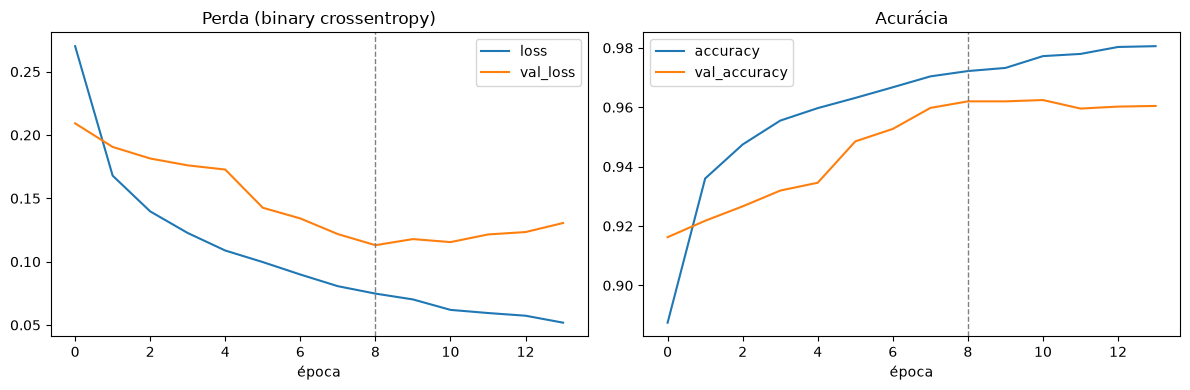

melhor época: 9 de 14 (pesos restaurados para ela)


In [8]:
h = pd.DataFrame(historico.history)
melhor = h["val_loss"].idxmin()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
h[["loss", "val_loss"]].plot(ax=a1, title="Perda (binary crossentropy)")
h[["accuracy", "val_accuracy"]].plot(ax=a2, title="Acurácia")
for a in (a1, a2):
    a.axvline(melhor, color="gray", ls="--", lw=1)
    a.set_xlabel("época")
plt.tight_layout()
plt.show()
print(f"melhor época: {melhor + 1} de {len(h)} (pesos restaurados para ela)")

## 7. Avaliação no teste (proporção real)

A comparação é com o **modelo ingênuo**, que responde sempre "normal". Ele
mostra quanto da acurácia é mérito do modelo e quanto é só o desbalanceio.

Métricas, com **anormal** como a classe positiva:

- **Acurácia:** % de acertos no total.
- **Recall (sensibilidade):** dos batimentos **realmente anormais**, quantos a
  rede detectou. É a métrica principal: uma anomalia não detectada é o erro
  perigoso.
- **Precisão:** dos que a rede **chamou** de anormais, quantos realmente
  eram. Mede os alarmes falsos.

In [9]:
prob_teste = modelo.predict(X_teste, verbose=0)[:, 0]
pred_teste = (prob_teste >= 0.5).astype(int)
pred_ingenuo = np.zeros_like(y_teste)  # sempre "normal"


def metricas(y, pred):
    return {"acurácia": accuracy_score(y, pred),
            "recall (anormal)": recall_score(y, pred, zero_division=0),
            "precisão (anormal)": precision_score(y, pred, zero_division=0),
            "anomalias perdidas": int(((y == 1) & (pred == 0)).sum()),
            "alarmes falsos": int(((y == 0) & (pred == 1)).sum())}


pd.DataFrame({"sempre 'normal'": metricas(y_teste, pred_ingenuo),
              "MLP": metricas(y_teste, pred_teste)}).T.round(4)

,acurácia,recall (anormal),precisão (anormal),anomalias perdidas,alarmes falsos
sempre 'normal',0.8276,0.0000,0.000,3774.0,0.0
MLP,0.9587,0.9494,0.834,191.0,713.0


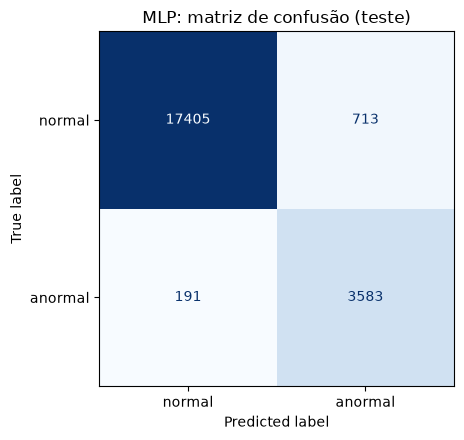

              precision    recall  f1-score   support

      normal     0.9891    0.9606    0.9747     18118
     anormal     0.8340    0.9494    0.8880      3774

    accuracy                         0.9587     21892
   macro avg     0.9116    0.9550    0.9313     21892
weighted avg     0.9624    0.9587    0.9597     21892



In [10]:
fig, eixo = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_teste, pred_teste, display_labels=["normal", "anormal"],
                                        cmap="Blues", colorbar=False, values_format="d", ax=eixo)
eixo.set_title("MLP: matriz de confusão (teste)")
plt.tight_layout()
plt.show()
print(classification_report(y_teste, pred_teste, target_names=["normal", "anormal"], digits=4))

### Recall por tipo de anomalia

O rótulo "anormal" junta quatro tipos bem diferentes. A taxa de detecção de
cada um mostra **onde** a rede falha.

In [11]:
por_tipo = pd.DataFrame([
    {"tipo": NOMES_CLASSE[c],
     "batimentos no teste": int((classe_teste_orig == c).sum()),
     "detectados como anormal": int((pred_teste[classe_teste_orig == c] == 1).sum()),
     "recall": (pred_teste[classe_teste_orig == c] == 1).mean()}
    for c in range(1, 5)]).set_index("tipo")
por_tipo.round(3)

,batimentos no teste,detectados como anormal,recall
tipo,,,
S (supraventricular),556,439,0.790
V (ventricular),1448,1414,0.977
F (fusão),162,143,0.883
Q (não classificável),1608,1587,0.987


### O limiar de decisão

Até aqui, "anormal" significa P(anormal) ≥ 0,5. Esse limiar é uma escolha.
Baixá-lo detecta mais anomalias, ao custo de mais alarmes falsos.

In [12]:
pd.DataFrame({f"limiar {t}": metricas(y_teste, (prob_teste >= t).astype(int))
              for t in (0.3, 0.5, 0.7)}).T.round(4)

,acurácia,recall (anormal),precisão (anormal),anomalias perdidas,alarmes falsos
limiar 0.3,0.9427,0.9634,0.7650,138.0,1117.0
limiar 0.5,0.9587,0.9494,0.8340,191.0,713.0
limiar 0.7,0.9681,0.9372,0.8845,237.0,462.0


### Resolução de entrada: 32×32 contra 64×64

A mesma arquitetura, treinada do mesmo jeito, com imagens de 64×64 (4.096
entradas, 4 vezes mais) para verificar se a resolução menor perde informação.

In [13]:
def treinar_mlp(X, y, lado):
    keras.utils.set_random_seed(SEED)
    m = keras.Sequential([keras.Input(shape=(lado * lado,)),
                          keras.layers.Dense(256, activation="relu"), keras.layers.Dropout(0.3),
                          keras.layers.Dense(128, activation="relu"), keras.layers.Dropout(0.3),
                          keras.layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer="adam", loss="binary_crossentropy")
    m.fit(X, y, validation_split=0.15, epochs=50, batch_size=128, verbose=0,
          callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                                   restore_best_weights=True)])
    return m


def entrada_lado(sinais, lado, lote=2000):
    return np.concatenate([preprocessar(renderizar(sinais[i:i + lote]), lado)
                           for i in range(0, len(sinais), lote)])


X_treino_64 = entrada_lado(sinais_treino[selecao], 64)
X_teste_64 = entrada_lado(sinais_teste, 64)
modelo_64 = treinar_mlp(X_treino_64, y_treino, 64)
pred_64 = (modelo_64.predict(X_teste_64, verbose=0)[:, 0] >= 0.5).astype(int)

comparacao = pd.DataFrame({"32×32 (1.024 entradas)": metricas(y_teste, pred_teste),
                           "64×64 (4.096 entradas)": metricas(y_teste, pred_64)}).T
comparacao["parâmetros"] = [modelo.count_params(), modelo_64.count_params()]
del X_treino_64, X_teste_64  # libera ~600 MB
comparacao.round(4)

,acurácia,recall (anormal),precisão (anormal),anomalias perdidas,alarmes falsos,parâmetros
32×32 (1.024 entradas),0.9587,0.9494,0.8340,191.0,713.0,295425
64×64 (4.096 entradas),0.9498,0.9557,0.7945,167.0,933.0,1081857


## 8. Análise dos resultados

### 8.1 O que a rede conseguiu

| | Sempre "normal" | MLP |
|---|---|---|
| Acurácia | 82,8% | **95,9%** |
| Recall (anormal) | 0% | **94,9%** |
| Anomalias perdidas (de 3.774) | 3.774 | **191** |
| Alarmes falsos (de 18.118 normais) | 0 | 713 (3,9%) |

A acurácia de 95,9% só faz sentido ao lado da linha de base: **82,8% vinham
de graça** do desbalanceio. O ganho real aparece no recall, que vai de 0% para
94,9%. A rede detecta 19 de cada 20 batimentos anormais.

### 8.2 Precisão de 83%: o preço do treino balanceado

De cada 100 batimentos que a rede chama de anormais, 83 realmente são. Os 713
alarmes falsos têm uma causa conhecida. A rede treinou vendo **50% de
anormais**, mas no teste eles são **17%**. Ela aprendeu uma noção de "quão
comum é uma anomalia" maior que a real, e por isso erra mais para o lado do
alarme. É uma troca consciente: em triagem, um alarme falso custa uma segunda
olhada, enquanto uma anomalia perdida pode custar muito mais.

A tabela de limiares mostra a mesma troca de forma explícita:

- **limiar 0,3:** perde 138 anomalias, gera 1.117 alarmes falsos
- **limiar 0,5:** perde 191, gera 713
- **limiar 0,7:** perde 237, gera 462

Não existe limiar "certo". A escolha depende de quanto custa um alarme falso
(tempo de um especialista) contra uma anomalia perdida, e é uma **decisão
clínica e operacional**, não técnica.

### 8.3 Onde a rede erra: batimentos supraventriculares

| Tipo | Recall | Leitura |
|---|---|---|
| Q (não classificável / marcapasso) | 98,7% | Formato muito distinto, inclusive a espícula do marcapasso. |
| V (ventricular) | 97,7% | O QRS largo e deformado é fácil de ver na imagem. |
| F (fusão) | 88,3% | Mistura de normal com ventricular, então a forma fica no meio do caminho. |
| **S (supraventricular)** | **79,0%** | **1 em cada 5 passa despercebido.** |

O batimento **S** nasce nos átrios, mas percorre os ventrículos pelo caminho
normal. Por isso o **formato** do complexo QRS fica parecido com o de um
batimento normal. O que o denuncia é principalmente o **momento** em que ocorre
(ele chega antes da hora) e alterações na onda P. A imagem de **um batimento
isolado** não carrega esse contexto de ritmo: a rede vê a forma, não o tempo
entre um batimento e o anterior. É uma limitação da **representação dos
dados**, não da quantidade de treino.

### 8.4 Sobreajuste visível na curva de treino

A perda de treino cai até o fim, mas a de **validação** para de melhorar por
volta da época 9 e depois sobe. A partir daí a rede passa a **decorar** o
treino, em vez de aprender padrões que generalizam. O **EarlyStopping**
detectou isso, interrompeu o treino e restaurou os pesos da melhor época. Sem
ele, o modelo final seria pior no teste.

### 8.5 Resolução: 32×32 é suficiente

Com 64×64, a rede detecta 24 anomalias a mais (recall de 95,6% contra 94,9%),
mas gera 220 alarmes falsos a mais (precisão de 79,5% contra 83,4%) e tem
**3,7 vezes mais parâmetros** (1,08 milhão contra 295 mil). Não há ganho claro
que justifique o custo. A forma do batimento já está legível em 32×32, como
mostra a figura da seção 3.

### 8.6 Limitações

- **MLP não enxerga a imagem como imagem.** Ao achatar 32×32 em 1.024 números,
  a rede perde a noção de que um pixel é vizinho do outro. Se o mesmo
  batimento aparecer deslocado alguns pixels, para a MLP é uma entrada
  totalmente diferente. Uma **CNN (rede convolucional)**, que analisa
  vizinhanças de pixels, é o passo natural seguinte.
- **A conversão para imagem foi uma escolha didática.** O dataset original é
  um sinal de 187 números, e transformá-lo em imagem atende à proposta de
  diagnóstico **visual** do enunciado. Não medimos se uma MLP sobre o sinal
  bruto faria melhor ou pior.
- **Treino e teste podem compartilhar pacientes.** O dataset não informa de
  qual paciente veio cada batimento, então não há como garantir que o teste
  tenha pacientes que a rede nunca viu. Se houver sobreposição, o desempenho
  medido é otimista: a rede pode estar reconhecendo o "jeito" do ECG de cada
  pessoa.
- **Um batimento, uma derivação.** Um ECG clínico tem 12 derivações e vários
  segundos de ritmo. Aqui há um único batimento de uma única derivação.

### 8.7 Vieses e governança

- **População pequena e antiga:** 47 pacientes, gravados entre 1975 e 1979 em
  um único hospital de Boston. Não há como afirmar que o modelo se comporta
  igual em outras populações, faixas etárias ou equipamentos. É o mesmo tipo
  de viés de **centro único** documentado para as imagens de ECG da Fase 1
  (`fase1/docs/VIESES.md`).
- **Mudança de domínio:** as imagens de ECG da Fase 1 são fotos de traçados de
  12 derivações em papel milimetrado. Um modelo treinado aqui, em batimentos
  isolados desenhados sobre fundo limpo, **não funcionaria** naquelas imagens
  sem novo treinamento. Desempenho em um dataset não se transfere
  automaticamente para outro.
- **Uso:** como as outras partes, este modelo é apoio à triagem. Ele pode
  ordenar quais traçados um especialista deve ver primeiro, mas não substitui
  a leitura do ECG.


## 9. Demonstração

Batimentos sorteados do teste, com a imagem que a rede recebe, o rótulo real
e a probabilidade prevista.

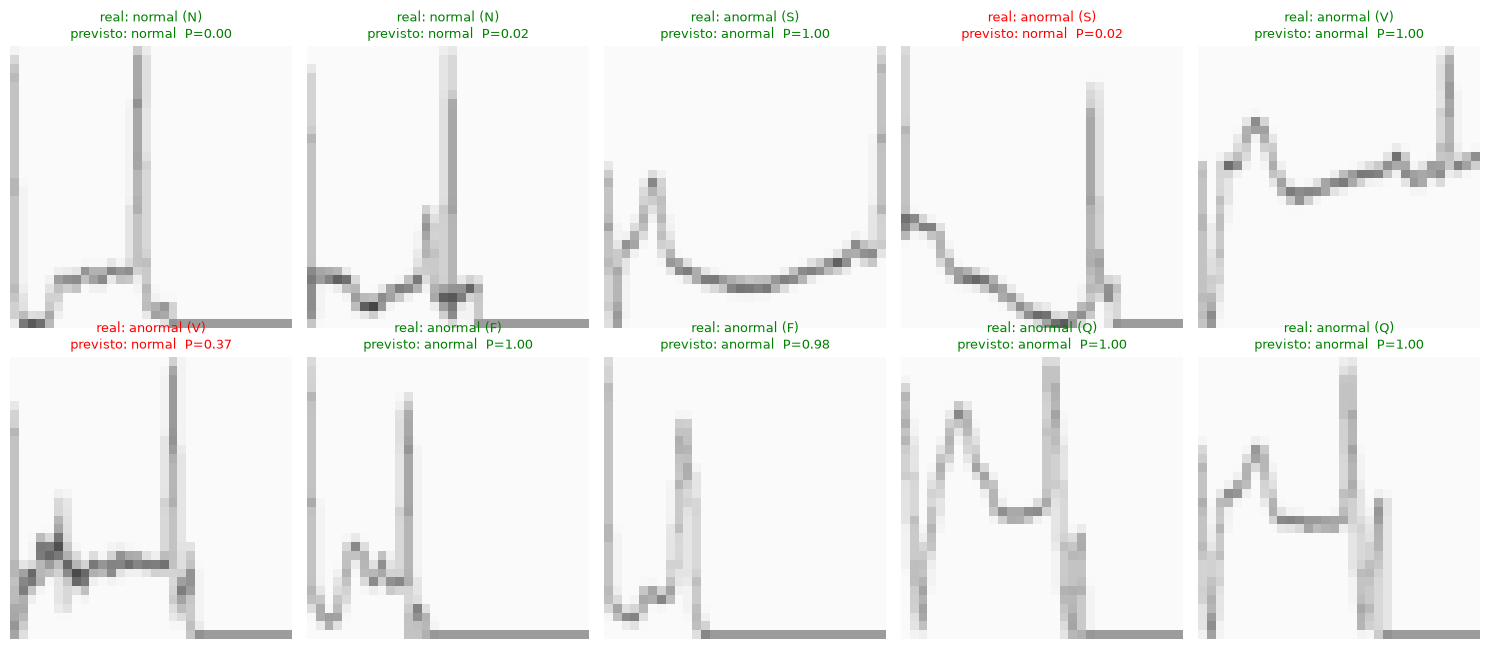

In [14]:
rng_demo = np.random.default_rng(7)
amostra = np.concatenate([rng_demo.choice(np.flatnonzero(classe_teste_orig == c), 2, replace=False)
                          for c in range(5)])
fig, eixos = plt.subplots(2, 5, figsize=(15, 6.5))
for eixo, i in zip(eixos.ravel(), amostra):
    real = "normal" if y_teste[i] == 0 else "anormal"
    previsto = "anormal" if pred_teste[i] else "normal"
    eixo.imshow(X_teste[i].reshape(LADO, LADO), cmap="gray_r", vmin=0, vmax=1)
    eixo.set_title(f"real: {real} ({NOMES_CLASSE[classe_teste_orig[i]].split()[0]})\n"
                   f"previsto: {previsto}  P={prob_teste[i]:.2f}",
                   fontsize=9, color="green" if real == previsto else "red")
    eixo.axis("off")
plt.tight_layout()
plt.show()